# AlphaEvolve HCLS Demo: Fast DNA Sequence Alignment Visualization

This notebook visualizes the results of running AlphaEvolve to optimize a local sequence alignment heuristic.

The goal is to evolve a python function `align_sequences` that approximates the optimal Smith-Waterman score but runs much faster (sub-quadratic time complexity).

The fitness metric is **Alignment Efficiency**, which combines:
* **Accuracy**: Ratio of the evolved alignment score to the optimal score (requires >= 80% accuracy to get score).
* **Speedup**: Relative execution speed compared to the full $O(N^2)$ baseline.

## Run Instructions

1. Make sure you have set up Application Default Credentials (ADC):
   ```bash
   gcloud auth application-default login
   ```
2. Run the evolution from the `src` directory specifying the config and a new engine ID:
   ```bash
   cd src
   ../venv/bin/python run.py \
     --problem_config ./data/problem_config/sequence_alignment.yaml \
     --engine alpha-evolve-sequence-alignment
   ```
   This will run the evolution and write logs to `src/evolution_log.jsonl`.
3. Run the cells below to visualize the progress and analyze the evolved code.

In [1]:
# @title Colab Setup
import os
import sys

# Detect if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Authenticating user for GCP...")
    from google.colab import auth
    auth.authenticate_user()
    print("Authenticated!")

    REPO_NAME = "alpha-evolve-demo"
    REPO_URL = f"https://github.com/goriri/{REPO_NAME}.git"
    
    if not os.path.exists(REPO_NAME):
        print(f"Cloning {REPO_URL}...")
        try:
            os.system(f"git clone {REPO_URL}")
            if os.path.exists(REPO_NAME):
                sys.path.append(os.path.abspath(REPO_NAME))
                os.chdir(REPO_NAME)
                print(f"Changed directory to {os.getcwd()}")
            else:
                print("Clone failed, directory not found.")
        except Exception as e:
            print(f"Failed to clone repository: {e}")
    else:
        sys.path.append(os.path.abspath(REPO_NAME))
        os.chdir(REPO_NAME)
        print(f"Repository already exists. Changed directory to {os.getcwd()}")

    if os.path.exists("src/requirements.txt"):
        print("Installing dependencies...")
        os.system("pip install -r src/requirements.txt")
        print("Dependencies installed!")
else:
    print("Running in local environment.")
    print("Ensure you have run 'gcloud auth application-default login' to set up ADC if you plan to run evolution.")

Running in local environment.
Ensure you have run 'gcloud auth application-default login' to set up ADC if you plan to run evolution.


In [2]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np

log_path = 'src/evolution_log.jsonl'

def load_logs(path):
    if not os.path.exists(path):
        return None
    
    logs = []
    with open(path, 'r') as f:
        for line in f:
            if line.strip():
                logs.append(json.loads(line))
    return logs

logs = load_logs(log_path)
if logs is not None:
    print(f"Loaded {len(logs)} log entries from {log_path}.")
else:
    print("No log files found. Please run the evolution first to generate results.")
    logs = []

Loaded 49 log entries from src/evolution_log.jsonl.


## 1. Optimization Progress

The cell below plots the progress of the evolution.
*   **Blue dots** show the efficiency score of individual trial programs.
*   **Green line** shows the cumulative best efficiency score.
*   Max theoretical score is 150 (100% accuracy + 10x speedup).

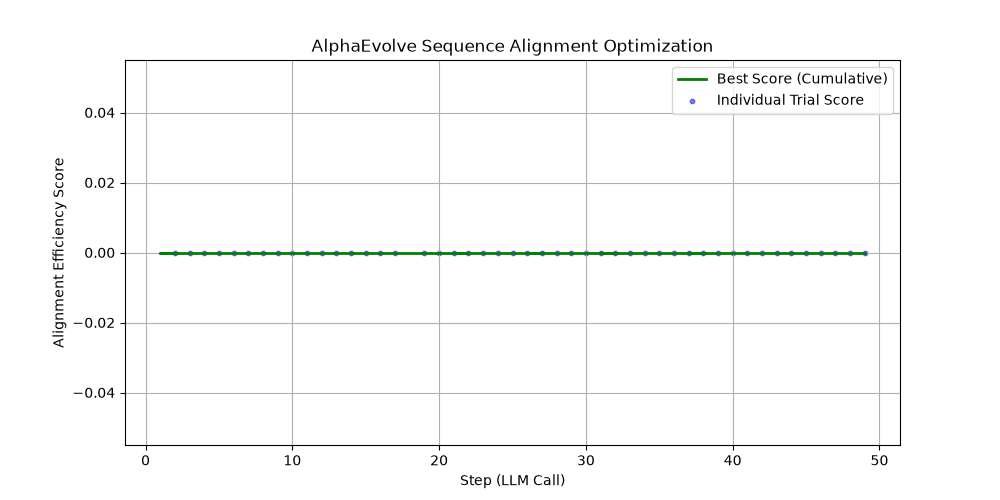

In [3]:
if logs:
    steps = [entry['step'] for entry in logs]
    
    scores = []
    best_scores = []
    for entry in logs:
        if entry['status'] == 'success':
            scores.append(entry['scores'].get('alignment_efficiency', 0))
        else:
            scores.append(None)
        
        best_scores.append(entry['best_scores'].get('scores_to_optimize/alignment_efficiency', 0))
        
    plt.figure(figsize=(10, 5))
    plt.plot(steps, best_scores, label='Best Score (Cumulative)', color='green', linewidth=2)
    plt.scatter([s for s, sc in zip(steps, scores) if sc is not None], 
                [sc for sc in scores if sc is not None], 
                alpha=0.5, label='Individual Trial Score', color='blue', s=10)
    
    plt.xlabel('Step (LLM Call)')
    plt.ylabel('Alignment Efficiency Score')
    plt.title('AlphaEvolve Sequence Alignment Optimization')
    plt.legend()
    plt.grid(True)
    plt.savefig('progress_alignment.png')
    plt.close()
    from IPython.display import Image, display
    display(Image(filename='progress_alignment.png'))
else:
    print("No logs to plot.")

## 2. Code Changes

Below we compare the best evolved program with the initial banded baseline using a git-style diff.

In [4]:
import difflib
import os
from IPython.display import display, HTML

initial_code_path = 'src/data/initial_programs/sequence_alignment.py'
if os.path.exists(initial_code_path):
    with open(initial_code_path, 'r') as f:
        initial_code = f.read()
else:
    initial_code = ""
    print(f"Initial code not found at {initial_code_path}")

def show_git_style_diff(old_text, new_text, fromfile='old', tofile='new'):
    diff = difflib.unified_diff(
        old_text.splitlines(),
        new_text.splitlines(),
        fromfile=fromfile,
        tofile=tofile,
        lineterm=''
    )
    
    html_lines = []
    html_lines.append("<pre style='font-family: monospace; background-color: #f6f8fa; padding: 16px; border-radius: 6px; line-height: 1.45; overflow: auto; text-align: left;'>")
    
    for line in diff:
        escaped_line = line.replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')
        if line.startswith('+') and not line.startswith('+++'):
            html_lines.append(f"<span style='background-color: #e6ffec; color: #22863a; display: block;'>{escaped_line}</span>")
        elif line.startswith('-') and not line.startswith('---'):
            html_lines.append(f"<span style='background-color: #ffeef0; color: #cb2431; display: block;'>{escaped_line}</span>")
        elif line.startswith('@@'):
            html_lines.append(f"<span style='color: #6f42c1; background-color: #f1f8ff; display: block;'>{escaped_line}</span>")
        elif line.startswith('---') or line.startswith('+++'):
            html_lines.append(f"<span style='font-weight: bold; color: #24292e; display: block;'>{escaped_line}</span>")
        else:
            html_lines.append(f"<span style='color: #24292e; display: block;'>{escaped_line}</span>")
            
    html_lines.append("</pre>")
    display(HTML('\n'.join(html_lines)))

if logs:
    successful_entries = [e for e in logs if e['status'] == 'success']
    if successful_entries:
        best_entry = max(successful_entries, key=lambda e: e['scores'].get('alignment_efficiency', 0))
        best_code = best_entry['program']
        print(f"Best score found: {best_entry['scores'].get('alignment_efficiency', 0):.2f} at step {best_entry['step']}")
        if initial_code:
            show_git_style_diff(initial_code, best_code, fromfile='initial_program.py', tofile='best_evolved_program.py')
    else:
        print("No successful steps in logs.")
else:
    print("No logs available.")

Best score found: 0.00 at step 2


### Heuristic Analysis

Analyzing the diff, look for how the LLM improved the alignment algorithm:
*   **Seed Detection**: Did it implement a hashing mechanism to find matching k-mers (seeds) first?
*   **Adaptive Banding**: Did it dynamically shift or widen the DP band based on seed locations or path scores?
*   **Early Exit**: Did it implement threshold checks to stop extending alignments that fall below a certain quality?
*   **Data Structure Optimization**: Did it replace dicts/lists with pre-allocated numpy arrays or flat arrays for faster lookups?